In [ ]:
# Download the Medical Cost Personal Insurance Dataset
!kaggle datasets download -d mirichoi0218/insurance

!unzip insurance.zip

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 29.6MB/s]

Archive:  insurance.zip
  inflating: insurance.csv           


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('insurance.csv')

print('First 5 Records:')
print(df.head())

print('Dataset info')
print(df.info())

print("\nTarget Variable: charges")
print("Numerical Features: age, bmi, children")
print("Categorical Features: sex, smoker, region")


First 5 Records:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Target Variable: charges
Numerical Features: age, bmi, child

In [4]:
from sklearn.model_selection import train_test_split

print('Missing values:')
print(df.isnull().sum())

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'\nTesting set size: {X_test.shape[0]} samples')


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Training set size: 1070 samples

Testing set size: 268 samples


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Performance
Mean Absolute Error:  4181.19
Mean Squared Error:  33596915.85
R-Squared Score:  0.78


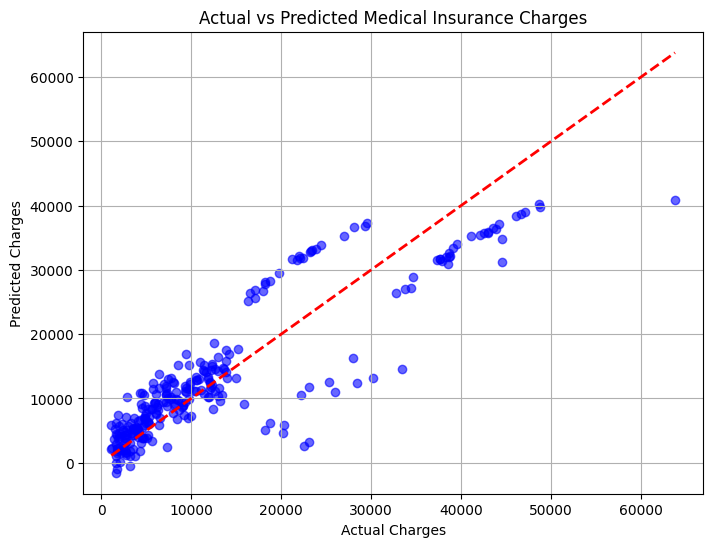

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Model Performance')
print(f'Mean Absolute Error:  {mae:.2f}')
print(f'Mean Squared Error:  {mse:.2f}')
print(f'R-Squared Score:  {r2:.2f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Insurance Charges')
plt.grid(True)
plt.show()